<a href="https://colab.research.google.com/github/TranQuocHuy83/mlops_training---module03---HuyTran-/blob/main/06_complete_classification_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
"""
Exercise 6: Complete Classification Workflow
Neural Network Classification - Module 3

This exercise covers:
- End-to-end binary classification workflow
- End-to-end multi-class workflow
- Hyperparameter experimentation
- Model comparison and selection
- Saving and loading trained models

Learning Mottos:
- If in doubt, run the code!
- Experiment, experiment, experiment!
- Visualize, visualize, visualize!
"""

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np
import pickle
from pathlib import Path

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# ============================================
# Part 1: Complete Binary Classification Workflow
# ============================================

In [2]:
print("=" * 60)
print("Part 1: Complete Binary Classification Workflow")
print("=" * 60)

# Step 1: Create data
print("\nStep 1: Creating data...")
X, y = make_circles(n_samples=1000, noise=0.03, factor=0.5, random_state=42)

# Step 2: Split data
print("Step 2: Splitting data...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3: Convert to tensors
print("Step 3: Converting to tensors...")
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train).unsqueeze(1)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test).unsqueeze(1)

# Step 4: Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Step 4: Using device: {device}")

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Step 5: Define model
print("Step 5: Building model...")
class BinaryClassifier(nn.Module):
    def __init__(self, hidden_units=[16, 8]):
        super(BinaryClassifier, self).__init__()
        layers = []
        prev_size = 2
        for hidden_size in hidden_units:
            layers.extend([nn.Linear(prev_size, hidden_size), nn.ReLU()])
            prev_size = hidden_size
        layers.append(nn.Linear(prev_size, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

model = BinaryClassifier(hidden_units=[16, 8]).to(device)

# Step 6: Define loss and optimizer
print("Step 6: Setting up loss and optimizer...")
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Step 7: Train model
print("Step 7: Training model...")
epochs = 100
train_losses = []
test_losses = []

for epoch in range(epochs):
    model.train()
    y_logits = model(X_train)
    loss = criterion(y_logits, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_loss = criterion(test_logits, y_test)
        test_losses.append(test_loss.item())

    if (epoch + 1) % 20 == 0:
        print(f'  Epoch [{epoch+1}/{epochs}], Train Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f}')

# Step 8: Evaluate
print("Step 8: Evaluating model...")
model.eval()
with torch.inference_mode():
    test_probs = torch.sigmoid(model(X_test))
    test_preds = (test_probs > 0.5).long()

accuracy = (test_preds == y_test).float().mean()
print(f"Binary Classification Accuracy: {accuracy.item()*100:.2f}%")

Part 1: Complete Binary Classification Workflow

Step 1: Creating data...
Step 2: Splitting data...
Step 3: Converting to tensors...
Step 4: Using device: cpu
Step 5: Building model...
Step 6: Setting up loss and optimizer...
Step 7: Training model...
  Epoch [20/100], Train Loss: 0.6375, Test Loss: 0.6380
  Epoch [40/100], Train Loss: 0.4433, Test Loss: 0.4594
  Epoch [60/100], Train Loss: 0.1603, Test Loss: 0.1719
  Epoch [80/100], Train Loss: 0.0372, Test Loss: 0.0436
  Epoch [100/100], Train Loss: 0.0126, Test Loss: 0.0159
Step 8: Evaluating model...
Binary Classification Accuracy: 100.00%


# ============================================
# Part 2: Complete Multi-Class Workflow
# ============================================

In [3]:
print("\n" + "=" * 60)
print("Part 2: Complete Multi-Class Workflow")
print("=" * 60)

# Create multi-class data
print("\nCreating multi-class data...")
X_multi, y_multi = make_blobs(n_samples=1000, n_features=2, centers=4, random_state=42)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)

X_train_m = torch.FloatTensor(X_train_m)
y_train_m = torch.LongTensor(y_train_m)
X_test_m = torch.FloatTensor(X_test_m)
y_test_m = torch.LongTensor(y_test_m)

X_train_m, y_train_m = X_train_m.to(device), y_train_m.to(device)
X_test_m, y_test_m = X_test_m.to(device), y_test_m.to(device)

# Define multi-class model
class MultiClassClassifier(nn.Module):
    def __init__(self, num_classes=4, hidden_units=[16, 8]):
        super(MultiClassClassifier, self).__init__()
        layers = []
        prev_size = 2
        for hidden_size in hidden_units:
            layers.extend([nn.Linear(prev_size, hidden_size), nn.ReLU()])
            prev_size = hidden_size
        layers.append(nn.Linear(prev_size, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

model_m = MultiClassClassifier(num_classes=4, hidden_units=[16, 8]).to(device)

# Train
print("Training multi-class model...")
criterion_m = nn.CrossEntropyLoss()
optimizer_m = optim.Adam(model_m.parameters(), lr=0.01)

for epoch in range(100):
    model_m.train()
    outputs = model_m(X_train_m)
    loss = criterion_m(outputs, y_train_m)
    optimizer_m.zero_grad()
    loss.backward()
    optimizer_m.step()

    if (epoch + 1) % 20 == 0:
        print(f'  Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

# Evaluate
model_m.eval()
with torch.inference_mode():
    test_preds_m = torch.argmax(model_m(X_test_m), dim=1)

accuracy_m = (test_preds_m == y_test_m).float().mean()
print(f"Multi-class Accuracy: {accuracy_m.item()*100:.2f}%")


Part 2: Complete Multi-Class Workflow

Creating multi-class data...
Training multi-class model...
  Epoch [20/100], Loss: 0.6416
  Epoch [40/100], Loss: 0.0708
  Epoch [60/100], Loss: 0.0058
  Epoch [80/100], Loss: 0.0034
  Epoch [100/100], Loss: 0.0029
Multi-class Accuracy: 100.00%


# ============================================
# Part 3: Hyperparameter Experimentation
# ============================================

In [4]:
print("\n" + "=" * 60)
print("Part 3: Hyperparameter Experimentation")
print("=" * 60)

def train_and_evaluate(hidden_units, learning_rate, epochs=100):
    """Train model with given hyperparameters"""
    # Create model
    model = BinaryClassifier(hidden_units=hidden_units).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Train
    for epoch in range(epochs):
        model.train()
        y_logits = model(X_train)
        loss = criterion(y_logits, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Evaluate
    model.eval()
    with torch.inference_mode():
        test_preds = (torch.sigmoid(model(X_test)) > 0.5).long()
        accuracy = (test_preds == y_test).float().mean()

    return accuracy.item()

# Experiment with different configurations
configs = [
    {'hidden_units': [8], 'lr': 0.01},
    {'hidden_units': [16], 'lr': 0.01},
    {'hidden_units': [16, 8], 'lr': 0.01},
    {'hidden_units': [32, 16], 'lr': 0.001},
    {'hidden_units': [64, 32, 16], 'lr': 0.001},
]

print("\nTesting different configurations:")
results = []
for i, config in enumerate(configs):
    acc = train_and_evaluate(config['hidden_units'], config['lr'])
    results.append({**config, 'accuracy': acc})
    print(f"  Config {i+1}: hidden={config['hidden_units']}, lr={config['lr']}, Accuracy: {acc*100:.2f}%")

# Find best configuration
best_config = max(results, key=lambda x: x['accuracy'])
print(f"\nBest configuration: {best_config}")


Part 3: Hyperparameter Experimentation

Testing different configurations:
  Config 1: hidden=[8], lr=0.01, Accuracy: 95.00%
  Config 2: hidden=[16], lr=0.01, Accuracy: 100.00%
  Config 3: hidden=[16, 8], lr=0.01, Accuracy: 100.00%
  Config 4: hidden=[32, 16], lr=0.001, Accuracy: 100.00%
  Config 5: hidden=[64, 32, 16], lr=0.001, Accuracy: 100.00%

Best configuration: {'hidden_units': [16], 'lr': 0.01, 'accuracy': 1.0}


# ============================================
# Part 4: Model Comparison
# ============================================

In [5]:
print("\n" + "=" * 60)
print("Part 4: Model Comparison")
print("=" * 60)

# Train multiple models
models = {
    'Linear': BinaryClassifier(hidden_units=[]),
    'Small': BinaryClassifier(hidden_units=[8]),
    'Medium': BinaryClassifier(hidden_units=[16, 8]),
    'Large': BinaryClassifier(hidden_units=[32, 16]),
}

print("\nComparing different model sizes:")
comparison_results = {}

for name, model_comp in models.items():
    model_comp = model_comp.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model_comp.parameters(), lr=0.01)

    # Train
    for epoch in range(100):
        model_comp.train()
        y_logits = model_comp(X_train)
        loss = criterion(y_logits, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Evaluate
    model_comp.eval()
    with torch.inference_mode():
        test_preds = (torch.sigmoid(model_comp(X_test)) > 0.5).long()
        accuracy = (test_preds == y_test).float().mean()
        params = sum(p.numel() for p in model_comp.parameters())

    comparison_results[name] = {
        'accuracy': accuracy.item(),
        'parameters': params
    }
    print(f"  {name:8s}: Accuracy={accuracy.item()*100:5.2f}%, Parameters={params:,}")


Part 4: Model Comparison

Comparing different model sizes:
  Linear  : Accuracy=46.00%, Parameters=3
  Small   : Accuracy=75.00%, Parameters=33
  Medium  : Accuracy=100.00%, Parameters=193
  Large   : Accuracy=100.00%, Parameters=641


# ============================================
# Part 5: Saving and Loading Models
# ============================================

In [7]:
print("\n" + "=" * 60)
print("Part 5: Saving and Loading Models")
print("=" * 60)

# Create directory for saving models
model_dir = Path('saved_models')
model_dir.mkdir(exist_ok=True)

# Save model state dict
model_path = model_dir / 'binary_classifier.pth'
torch.save(model.state_dict(), model_path)
print(f"Model saved to: {model_path}")

# Load model
loaded_model = BinaryClassifier(hidden_units=[16, 8])
loaded_model.load_state_dict(torch.load(model_path))
loaded_model = loaded_model.to(device)
loaded_model.eval()
print("Model loaded successfully!")

# Verify loaded model works
with torch.inference_mode():
    test_preds_loaded = (torch.sigmoid(loaded_model(X_test)) > 0.5).long()
    accuracy_loaded = (test_preds_loaded == y_test).float().mean()
print(f"Loaded model accuracy: {accuracy_loaded.item()*100:.2f}%")

# Save complete model (including architecture)
complete_model_path = model_dir / 'binary_classifier_complete.pth'
torch.save(model, complete_model_path)
print(f"Complete model saved to: {complete_model_path}")

# Load complete model
loaded_complete = torch.load(complete_model_path, weights_only=False)
loaded_complete.eval()
print("Complete model loaded successfully!")


Part 5: Saving and Loading Models
Model saved to: saved_models/binary_classifier.pth
Model loaded successfully!
Loaded model accuracy: 100.00%
Complete model saved to: saved_models/binary_classifier_complete.pth
Complete model loaded successfully!


# ============================================
# Part 6: Model Inference Function
# ============================================

In [8]:
print("\n" + "=" * 60)
print("Part 6: Model Inference Function")
print("=" * 60)

def predict(model, X_new, device='cpu'):
    """Make predictions on new data"""
    model.eval()
    model = model.to(device)

    # Convert to tensor if needed
    if not isinstance(X_new, torch.Tensor):
        X_new = torch.FloatTensor(X_new)

    X_new = X_new.to(device)

    # Make prediction
    with torch.inference_mode():
        logits = model(X_new)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).long()

    return {
        'logits': logits.cpu(),
        'probabilities': probs.cpu(),
        'predictions': preds.cpu()
    }

# Test inference function
X_new = torch.randn(5, 2)
results = predict(model, X_new, device)

print("\nPredictions for 5 new samples:")
for i in range(5):
    print(f"  Sample {i+1}:")
    print(f"    Input: {X_new[i].numpy()}")
    print(f"    Probability: {results['probabilities'][i].item():.4f}")
    print(f"    Predicted class: {results['predictions'][i].item()}")


Part 6: Model Inference Function

Predictions for 5 new samples:
  Sample 1:
    Input: [-0.33317715 -0.9447482 ]
    Probability: 0.0044
    Predicted class: 0
  Sample 2:
    Input: [ 0.44379145 -2.0985024 ]
    Probability: 0.0000
    Predicted class: 0
  Sample 3:
    Input: [-0.7526791  1.5466937]
    Probability: 0.0000
    Predicted class: 0
  Sample 4:
    Input: [ 2.424221   -0.12996924]
    Probability: 0.0000
    Predicted class: 0
  Sample 5:
    Input: [1.0218663 1.4104029]
    Probability: 0.0000
    Predicted class: 0


# ============================================
# Part 7: Complete Training Class
# ============================================

In [9]:
print("\n" + "=" * 60)
print("Part 7: Complete Training Class")
print("=" * 60)

class ClassificationTrainer:
    """Complete training pipeline for classification"""

    def __init__(self, model, device='cpu'):
        self.model = model.to(device)
        self.device = device
        self.history = {'train_loss': [], 'test_loss': []}

    def train(self, X_train, y_train, X_test, y_test,
              epochs=100, lr=0.01):
        """Train the model"""
        criterion = nn.BCEWithLogitsLoss()
        optimizer = optim.Adam(self.model.parameters(), lr=lr)

        for epoch in range(epochs):
            # Training
            self.model.train()
            y_logits = self.model(X_train)
            loss = criterion(y_logits, y_train)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Testing
            self.model.eval()
            with torch.inference_mode():
                test_logits = self.model(X_test)
                test_loss = criterion(test_logits, y_test)

            self.history['train_loss'].append(loss.item())
            self.history['test_loss'].append(test_loss.item())

            if (epoch + 1) % 20 == 0:
                print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f}')

    def evaluate(self, X_test, y_test):
        """Evaluate the model"""
        self.model.eval()
        with torch.inference_mode():
            test_probs = torch.sigmoid(self.model(X_test))
            test_preds = (test_probs > 0.5).long()
            accuracy = (test_preds == y_test).float().mean()

        return accuracy.item()

    def save(self, path):
        """Save the model"""
        torch.save(self.model.state_dict(), path)
        print(f"Model saved to: {path}")

    def load(self, path):
        """Load the model"""
        self.model.load_state_dict(torch.load(path))
        print(f"Model loaded from: {path}")

# Use the trainer
print("\nUsing ClassificationTrainer:")
model_trainer = BinaryClassifier(hidden_units=[16, 8])
trainer = ClassificationTrainer(model_trainer, device=device)
trainer.train(X_train, y_train, X_test, y_test, epochs=100, lr=0.01)
accuracy_trainer = trainer.evaluate(X_test, y_test)
print(f"Final accuracy: {accuracy_trainer*100:.2f}%")

# Save the trained model
trainer.save(model_dir / 'trained_classifier.pth')


Part 7: Complete Training Class

Using ClassificationTrainer:
Epoch [20/100], Train Loss: 0.5840, Test Loss: 0.5822
Epoch [40/100], Train Loss: 0.2710, Test Loss: 0.2665
Epoch [60/100], Train Loss: 0.0460, Test Loss: 0.0466
Epoch [80/100], Train Loss: 0.0111, Test Loss: 0.0126
Epoch [100/100], Train Loss: 0.0054, Test Loss: 0.0065
Final accuracy: 100.00%
Model saved to: saved_models/trained_classifier.pth


# ============================================
# Part 8: Training Curves Visualization
# ============================================


Part 8: Training Curves Visualization


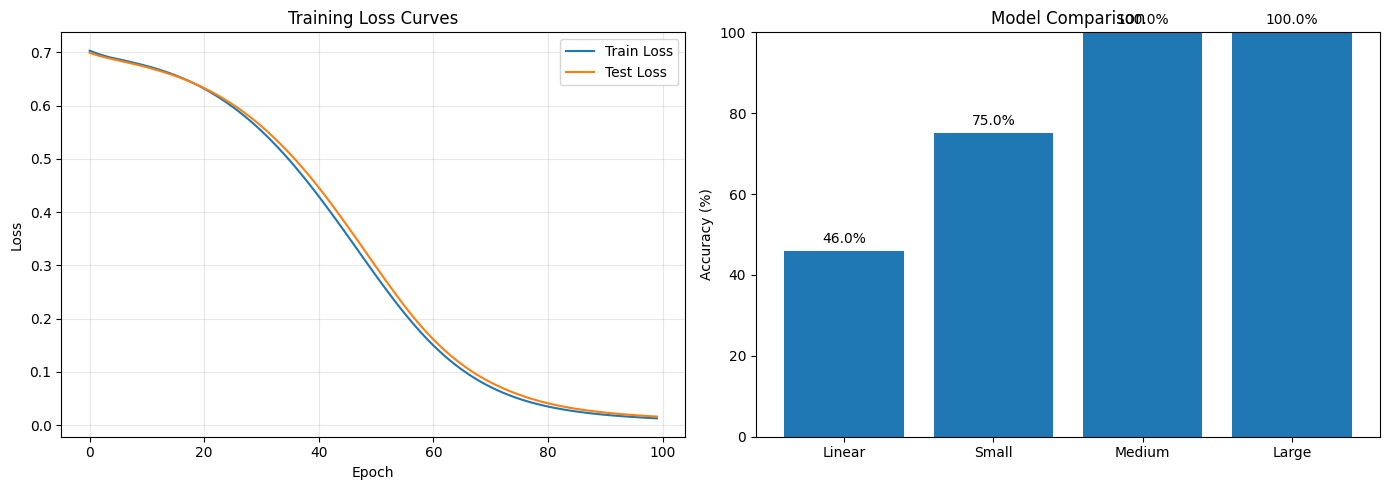

In [10]:
print("\n" + "=" * 60)
print("Part 8: Training Curves Visualization")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(test_losses, label='Test Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Model comparison
names = list(comparison_results.keys())
accuracies = [comparison_results[name]['accuracy'] * 100 for name in names]
axes[1].bar(names, accuracies)
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Model Comparison')
axes[1].set_ylim(0, 100)
for i, v in enumerate(accuracies):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()

# ============================================
# Exercises
# ============================================

In [13]:
print("\n" + "=" * 60)
print("Exercises")
print("=" * 60)

# Exercise 1: Design your own experiment
print("\nExercise 1: Design your own experiment")
print("Create and test your own model configuration:")
print("  - Try different architectures")
print("  - Try different learning rates")
print("  - Try different numbers of epochs")
print("Tip: Use the ClassificationTrainer class")


Exercises

Exercise 1: Design your own experiment
Create and test your own model configuration:
  - Try different architectures
  - Try different learning rates
  - Try different numbers of epochs
Tip: Use the ClassificationTrainer class


In [15]:
# 1. Create dataset (Binary Classification)

X, y = make_circles(n_samples=1000, noise=0.03, factor=0.5, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

device = "cuda" if torch.cuda.is_available() else "cpu"

X_train = torch.FloatTensor(X_train).to(device)
X_test  = torch.FloatTensor(X_test).to(device)
y_train = torch.FloatTensor(y_train).unsqueeze(1).to(device)
y_test  = torch.FloatTensor(y_test).unsqueeze(1).to(device)

# 2. Define Trainer Class

class ClassificationTrainer:
    def __init__(self, model, learning_rate=0.01, device="cpu"):
        self.model = model.to(device)
        self.device = device
        self.loss_fn = nn.BCEWithLogitsLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=learning_rate)

    def train(self, X, y, epochs=100):
        for epoch in range(epochs):
            self.model.train()
            logits = self.model(X)
            loss = self.loss_fn(logits, y)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

    def evaluate(self, X, y):
        self.model.eval()
        with torch.no_grad():
            logits = self.model(X)
            preds = torch.round(torch.sigmoid(logits))
            acc = accuracy_score(y.cpu(), preds.cpu())
        return acc

# 3. Define Experiments

architectures = [
    [8],
    [16],
    [16, 8],
    [32, 16]
]

learning_rates = [0.1, 0.01, 0.001]
epochs_list = [100, 300]

results = []

# 4. Run Experiments (Mini Grid Search)

for arch, lr, epochs in itertools.product(architectures, learning_rates, epochs_list):

    print(f"\nTesting config: hidden_layers={arch}, lr={lr}, epochs={epochs}")

    layers = []
    input_size = 2

    for hidden_units in arch:
        layers.append(nn.Linear(input_size, hidden_units))
        layers.append(nn.ReLU())
        input_size = hidden_units

    layers.append(nn.Linear(input_size, 1))
    model = nn.Sequential(*layers)

    trainer = ClassificationTrainer(model, learning_rate=lr, device=device)
    trainer.train(X_train, y_train, epochs=epochs)

    acc = trainer.evaluate(X_test, y_test)

    print(f"Accuracy: {acc*100:.2f}%")

    results.append({
        "architecture": arch,
        "learning_rate": lr,
        "epochs": epochs,
        "accuracy": acc
    })

# 5. Best Configuration

best_result = max(results, key=lambda x: x["accuracy"])

print("\n============================================================")
print("Best Configuration Found:")
print("------------------------------------------------------------")
print(f"Hidden Layers: {best_result['architecture']}")
print(f"Learning Rate: {best_result['learning_rate']}")
print(f"Epochs: {best_result['epochs']}")
print(f"Best Accuracy: {best_result['accuracy']*100:.2f}%")
print("============================================================")


Testing config: hidden_layers=[8], lr=0.1, epochs=100
Accuracy: 100.00%

Testing config: hidden_layers=[8], lr=0.1, epochs=300
Accuracy: 100.00%

Testing config: hidden_layers=[8], lr=0.01, epochs=100
Accuracy: 86.50%

Testing config: hidden_layers=[8], lr=0.01, epochs=300
Accuracy: 100.00%

Testing config: hidden_layers=[8], lr=0.001, epochs=100
Accuracy: 72.00%

Testing config: hidden_layers=[8], lr=0.001, epochs=300
Accuracy: 94.50%

Testing config: hidden_layers=[16], lr=0.1, epochs=100
Accuracy: 100.00%

Testing config: hidden_layers=[16], lr=0.1, epochs=300
Accuracy: 100.00%

Testing config: hidden_layers=[16], lr=0.01, epochs=100
Accuracy: 92.50%

Testing config: hidden_layers=[16], lr=0.01, epochs=300
Accuracy: 100.00%

Testing config: hidden_layers=[16], lr=0.001, epochs=100
Accuracy: 76.00%

Testing config: hidden_layers=[16], lr=0.001, epochs=300
Accuracy: 92.50%

Testing config: hidden_layers=[16, 8], lr=0.1, epochs=100
Accuracy: 100.00%

Testing config: hidden_layers=[16,

In [16]:
# Exercise 2: Compare on different datasets
print("\nExercise 2: Compare on different datasets")
print("Test models on different datasets:")
print("  - make_circles with different noise levels")
print("  - make_blobs with different number of classes")
print("Tip: Modify the data creation code")


Exercise 2: Compare on different datasets
Test models on different datasets:
  - make_circles with different noise levels
  - make_blobs with different number of classes
Tip: Modify the data creation code


In [20]:
# Binary
device = "cuda" if torch.cuda.is_available() else "cpu"

noise_levels = [0.01, 0.1, 0.2]

for noise in noise_levels:

    print(f"\nTesting noise level: {noise}")

    # Create dataset
    X, y = make_circles(n_samples=1000, noise=noise, factor=0.5, random_state=42)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    X_train = torch.FloatTensor(X_train).to(device)
    X_test  = torch.FloatTensor(X_test).to(device)
    y_train = torch.FloatTensor(y_train).unsqueeze(1).to(device)
    y_test  = torch.FloatTensor(y_test).unsqueeze(1).to(device)

    # Simple model
    model = nn.Sequential(
        nn.Linear(2, 16),
        nn.ReLU(),
        nn.Linear(16, 1)
    ).to(device)

    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    # Train
    for epoch in range(200):
        model.train()
        logits = model(X_train)
        loss = loss_fn(logits, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Evaluate
    model.eval()
    with torch.no_grad():
        preds = torch.round(torch.sigmoid(model(X_test)))
        acc = accuracy_score(y_test.cpu(), preds.cpu())

    print(f"Accuracy: {acc*100:.2f}%")


Testing noise level: 0.01
Accuracy: 100.00%

Testing noise level: 0.1
Accuracy: 96.50%

Testing noise level: 0.2
Accuracy: 79.00%


In [19]:
# Multi-class
device = "cuda" if torch.cuda.is_available() else "cpu"

num_classes_list = [3, 4, 6]

for num_classes in num_classes_list:

    print(f"\nTesting number of classes: {num_classes}")

    # Create dataset
    X, y = make_blobs(
        n_samples=1000,
        centers=num_classes,
        n_features=2,
        random_state=42
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    X_train = torch.FloatTensor(X_train).to(device)
    X_test  = torch.FloatTensor(X_test).to(device)
    y_train = torch.LongTensor(y_train).to(device)
    y_test  = torch.LongTensor(y_test).to(device)

    # Model
    model = nn.Sequential(
        nn.Linear(2, 32),
        nn.ReLU(),
        nn.Linear(32, num_classes)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    # Train
    for epoch in range(200):
        model.train()
        logits = model(X_train)
        loss = loss_fn(logits, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Evaluate
    model.eval()
    with torch.no_grad():
        preds = torch.argmax(model(X_test), dim=1)
        acc = accuracy_score(y_test.cpu(), preds.cpu())

    print(f"Accuracy: {acc*100:.2f}%")


Testing number of classes: 3
Accuracy: 100.00%

Testing number of classes: 4
Accuracy: 100.00%

Testing number of classes: 6
Accuracy: 94.00%


In [21]:
# Exercise 3: Implement early stopping
print("\nExercise 3: Implement early stopping")
print("Stop training when test loss stops improving:")
print("  - Track test loss each epoch")
print("  - Stop if no improvement for N epochs")
print("Tip: Add patience parameter to training loop")


Exercise 3: Implement early stopping
Stop training when test loss stops improving:
  - Track test loss each epoch
  - Stop if no improvement for N epochs
Tip: Add patience parameter to training loop


In [22]:
print("\n============================================================")
print("Exercise 3: Implement Early Stopping")
print("============================================================")

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

# 1. Create Dataset

X, y = make_circles(n_samples=1000, noise=0.1, factor=0.5, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

device = "cuda" if torch.cuda.is_available() else "cpu"

X_train = torch.FloatTensor(X_train).to(device)
X_test  = torch.FloatTensor(X_test).to(device)
y_train = torch.FloatTensor(y_train).unsqueeze(1).to(device)
y_test  = torch.FloatTensor(y_test).unsqueeze(1).to(device)

# 2. Define Model

model = nn.Sequential(
    nn.Linear(2, 32),
    nn.ReLU(),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
).to(device)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 3. Early Stopping Setup

epochs = 500
patience = 20   # số epoch cho phép không cải thiện
best_test_loss = float("inf")
patience_counter = 0

train_losses = []
test_losses = []

# 4. Training Loop with Early Stopping

for epoch in range(epochs):

    # ---- Training ----
    model.train()
    logits = model(X_train)
    train_loss = loss_fn(logits, y_train)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    # ---- Evaluation ----
    model.eval()
    with torch.no_grad():
        test_logits = model(X_test)
        test_loss = loss_fn(test_logits, y_test)

    train_losses.append(train_loss.item())
    test_losses.append(test_loss.item())

    # ---- Early Stopping Logic ----
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_model_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

    if (epoch+1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")

# 5. Load Best Model

model.load_state_dict(best_model_state)

# 6. Final Evaluation

model.eval()
with torch.no_grad():
    preds = torch.round(torch.sigmoid(model(X_test)))
    acc = accuracy_score(y_test.cpu(), preds.cpu())

print("\nFinal Test Accuracy (Best Model): {:.2f}%".format(acc*100))


Exercise 3: Implement Early Stopping
Epoch [50/500] - Train Loss: 0.0187, Test Loss: 0.0572
Epoch [100/500] - Train Loss: 0.0061, Test Loss: 0.0435
Epoch [150/500] - Train Loss: 0.0034, Test Loss: 0.0425
Epoch [200/500] - Train Loss: 0.0025, Test Loss: 0.0424

Early stopping triggered at epoch 212

Final Test Accuracy (Best Model): 98.00%


In [23]:
# Exercise 4: Create model comparison report
print("\nExercise 4: Create model comparison report")
print("Compare models and create a report:")
print("  - Test accuracy")
print("  - Number of parameters")
print("  - Training time")
print("Tip: Track training time with time.time()")


Exercise 4: Create model comparison report
Compare models and create a report:
  - Test accuracy
  - Number of parameters
  - Training time
Tip: Track training time with time.time()


In [26]:
import time
import pandas as pd
# 1. Create Dataset

X, y = make_circles(n_samples=1000, noise=0.1, factor=0.5, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

device = "cuda" if torch.cuda.is_available() else "cpu"

X_train = torch.FloatTensor(X_train).to(device)
X_test  = torch.FloatTensor(X_test).to(device)
y_train = torch.FloatTensor(y_train).unsqueeze(1).to(device)
y_test  = torch.FloatTensor(y_test).unsqueeze(1).to(device)

# 2. Define Models

models = {
    "Linear": nn.Sequential(
        nn.Linear(2, 1)
    ),

    "Small NN": nn.Sequential(
        nn.Linear(2, 16),
        nn.ReLU(),
        nn.Linear(16, 1)
    ),

    "Medium NN": nn.Sequential(
        nn.Linear(2, 32),
        nn.ReLU(),
        nn.Linear(32, 32),
        nn.ReLU(),
        nn.Linear(32, 1)
    ),

    "Large NN": nn.Sequential(
        nn.Linear(2, 64),
        nn.ReLU(),
        nn.Linear(64, 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 1)
    )
}

results = []

# 3. Train and Evaluate Each Model

for name, model in models.items():

    print(f"\nTraining {name}...")

    model = model.to(device)
    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    # Count parameters
    num_params = sum(p.numel() for p in model.parameters())

    # Track training time
    start_time = time.time()

    epochs = 300
    for epoch in range(epochs):
        model.train()
        logits = model(X_train)
        loss = loss_fn(logits, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    end_time = time.time()
    training_time = end_time - start_time

    # Evaluate
    model.eval()
    with torch.no_grad():
        preds = torch.round(torch.sigmoid(model(X_test)))
        acc = accuracy_score(y_test.cpu(), preds.cpu())

    results.append({
        "Model": name,
        "Accuracy": round(acc * 100, 2),
        "Parameters": num_params,
        "Training Time (s)": round(training_time, 4)
    })

# 4. Create Report

report_df = pd.DataFrame(results)

print("\n============================================================")
print("Model Comparison Report")
print("============================================================")
print(report_df)


Training Linear...

Training Small NN...

Training Medium NN...

Training Large NN...

Model Comparison Report
       Model  Accuracy  Parameters  Training Time (s)
0     Linear      46.0           3             0.5450
1   Small NN      97.5          65             0.6234
2  Medium NN      97.5        1185             0.7427
3   Large NN      97.0        6465             1.3223


In [27]:
# Exercise 5: Save/load with metadata
print("\nExercise 5: Save/load with metadata")
print("Save model with additional information:")
print("  - Hyperparameters")
print("  - Training metrics")
print("  - Date/time")
print("Tip: Use pickle or create a dictionary to save")

print("\n" + "=" * 60)
print("Exercise 6 Complete!")
print("Remember: If in doubt, run the code!")
print("Remember: Experiment, experiment, experiment!")
print("Remember: Visualize, visualize, visualize!")
print("=" * 60)


Exercise 5: Save/load with metadata
Save model with additional information:
  - Hyperparameters
  - Training metrics
  - Date/time
Tip: Use pickle or create a dictionary to save

Exercise 6 Complete!
Remember: If in doubt, run the code!
Remember: Experiment, experiment, experiment!
Remember: Visualize, visualize, visualize!


In [30]:
import datetime
import os
# 1. Create Dataset

X, y = make_circles(n_samples=1000, noise=0.1, factor=0.5, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

device = "cuda" if torch.cuda.is_available() else "cpu"

X_train = torch.FloatTensor(X_train).to(device)
X_test  = torch.FloatTensor(X_test).to(device)
y_train = torch.FloatTensor(y_train).unsqueeze(1).to(device)
y_test  = torch.FloatTensor(y_test).unsqueeze(1).to(device)

# 2. Define Model + Hyperparameters

hidden_units = 32
learning_rate = 0.01
epochs = 200

model = nn.Sequential(
    nn.Linear(2, hidden_units),
    nn.ReLU(),
    nn.Linear(hidden_units, 1)
).to(device)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# 3. Train Model

train_losses = []

for epoch in range(epochs):
    model.train()
    logits = model(X_train)
    loss = loss_fn(logits, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

# Evaluate
model.eval()
with torch.no_grad():
    preds = torch.round(torch.sigmoid(model(X_test)))
    accuracy = accuracy_score(y_test.cpu(), preds.cpu())

print(f"Final Accuracy: {accuracy*100:.2f}%")

# 4. Create Metadata Dictionary

metadata = {
    "model_state_dict": model.state_dict(),
    "hyperparameters": {
        "hidden_units": hidden_units,
        "learning_rate": learning_rate,
        "epochs": epochs
    },
    "training_metrics": {
        "final_accuracy": accuracy,
        "final_train_loss": train_losses[-1]
    },
    "date_time": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

# 5. Save Model

os.makedirs("saved_models", exist_ok=True)
save_path = "saved_models/model_with_metadata.pth"

torch.save(metadata, save_path)

print(f"Model saved to: {save_path}")

# 6. Load Model + Metadata

loaded_checkpoint = torch.load(save_path, weights_only=False)

print("\nLoaded Metadata:")
print("Hyperparameters:", loaded_checkpoint["hyperparameters"])
print("Training Metrics:", loaded_checkpoint["training_metrics"])
print("Saved at:", loaded_checkpoint["date_time"])

# Rebuild model
loaded_model = nn.Sequential(
    nn.Linear(2, loaded_checkpoint["hyperparameters"]["hidden_units"]),
    nn.ReLU(),
    nn.Linear(loaded_checkpoint["hyperparameters"]["hidden_units"], 1)
).to(device)

loaded_model.load_state_dict(loaded_checkpoint["model_state_dict"])
loaded_model.eval()

print("Model loaded successfully!")

Final Accuracy: 97.00%
Model saved to: saved_models/model_with_metadata.pth

Loaded Metadata:
Hyperparameters: {'hidden_units': 32, 'learning_rate': 0.01, 'epochs': 200}
Training Metrics: {'final_accuracy': 0.97, 'final_train_loss': 0.040917571634054184}
Saved at: 2026-03-02 02:09:21
Model loaded successfully!
